# Week 2 — Entanglement, Measurement, and Multi-Qubit Systems

**Quantum Artificial Intelligence**

---

One qubit is a point on a sphere; the real power of quantum computing appears only with **many**
qubits, because the state space grows *exponentially* and contains correlations with no classical
counterpart. This week we extend our from-scratch simulator to $n$ qubits via the tensor product,
formalize the **measurement** postulate (the Born rule and state collapse), build the **Bell states**,
and prove — numerically — that quantum correlations violate the **CHSH inequality**, something no
classical theory can do.

Roadmap:

1. **Multi-qubit states** and the tensor (Kronecker) product; the exponential state space.
2. **Two-qubit gates**: CNOT and the creation of entanglement.
3. **Measurement**: the Born rule, collapse, and partial measurement.
4. **Entanglement and CHSH**: Bell states and the experimental refutation of local realism.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

# Single-qubit building blocks from Week 1
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)


## 1. Multi-qubit states and the tensor product

Two classical bits have four configurations $00, 01, 10, 11$. Two qubits live in the **tensor
product** space $\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$, spanned by

$$
|00\rangle, |01\rangle, |10\rangle, |11\rangle,
$$

and a general state is a superposition over all four basis vectors with amplitudes summing (in
modulus squared) to one. For $n$ qubits the space is $\mathbb{C}^{2^n}$: the dimension **doubles with
each qubit**. Fifty qubits already require $2^{50}\approx 10^{15}$ amplitudes — the root of both
quantum computing's promise and the difficulty of simulating it classically.

The combined state of independent qubits is their **Kronecker product**. If qubit A is in
$|\psi\rangle$ and qubit B in $|\phi\rangle$, the joint state is $|\psi\rangle\otimes|\phi\rangle$,
computed by `np.kron`. Gates acting on individual qubits combine the same way: a gate $U$ on qubit 0
of a two-qubit register is $U \otimes I$. We build helpers to place a single-qubit gate on any wire of
an $n$-qubit system.


In [2]:
def kron_all(matrices):
    return reduce(np.kron, matrices)

def basis_state(bits):
    # bits e.g. '00' or '101' -> computational basis ket in C^{2^n}
    kets = [ket0 if b == '0' else ket1 for b in bits]
    return kron_all(kets)

def op_on(n, gate, target):
    # n-qubit operator applying `gate` on wire `target`, identity elsewhere.
    mats = [gate if w == target else I2 for w in range(n)]
    return kron_all(mats)

# Two independent qubits
psiA = H @ ket0            # |+>
psiB = ket1                # |1>
joint = np.kron(psiA, psiB)
print("|+> (x) |1> =", joint)
print("dimension of 2-qubit space:", joint.size)
print("dimension of 10-qubit space:", 2**10)

# Apply X to wire 1 of a 2-qubit |00>
state = basis_state('00')
state = op_on(2, X, target=1) @ state
print("\nX on wire 1 of |00> ->", state, " (= |01>)")


|+> (x) |1> = [0.    +0.j 0.7071+0.j 0.    +0.j 0.7071+0.j]
dimension of 2-qubit space: 4
dimension of 10-qubit space: 1024

X on wire 1 of |00> -> [0.+0.j 1.+0.j 0.+0.j 0.+0.j]  (= |01>)


## 2. Two-qubit gates and entanglement

A **two-qubit gate** is a $4\times4$ unitary acting on the joint space. The most important is the
**controlled-NOT (CNOT)**: it flips the target qubit if and only if the control qubit is $|1\rangle$.
In the basis $\{|00\rangle,|01\rangle,|10\rangle,|11\rangle\}$,

$$
\text{CNOT} = \begin{pmatrix} 1&0&0&0 \\ 0&1&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \end{pmatrix}.
$$

CNOT is the gate that creates **entanglement** — correlations between qubits that cannot be described
by giving each qubit its own state. The canonical recipe: apply $H$ to the control to make a
superposition, then CNOT. Starting from $|00\rangle$:

$$
|00\rangle \xrightarrow{H\otimes I} \tfrac{1}{\sqrt2}(|00\rangle + |10\rangle)
\xrightarrow{\text{CNOT}} \tfrac{1}{\sqrt2}(|00\rangle + |11\rangle) = |\Phi^+\rangle .
$$

The result $|\Phi^+\rangle$ is a **Bell state**. It cannot be written as $|\psi\rangle\otimes|\phi\rangle$
for any single-qubit states — the qubits have no individual identities, only a shared one. We verify
this entanglement by attempting (and failing) to factor it.


In [3]:
CNOT = np.array([[1,0,0,0],
                 [0,1,0,0],
                 [0,0,0,1],
                 [0,0,1,0]], dtype=complex)

# Build the Bell state |Phi+>
state = basis_state('00')
state = op_on(2, H, target=0) @ state      # H on control
state = CNOT @ state                        # entangle
print("Bell state |Phi+> =", state, " = (|00> + |11>)/sqrt(2)")

def is_product_state(psi2q, tol=1e-9):
    # A 2-qubit state is a product iff its 2x2 amplitude matrix has rank 1
    # (equivalently determinant a00*a11 - a01*a10 = 0).
    M = psi2q.reshape(2, 2)
    det = M[0,0]*M[1,1] - M[0,1]*M[1,0]
    return abs(det) < tol, det

prod, det = is_product_state(state)
print("\nIs |Phi+> a product state?", prod, " (determinant =", np.round(det,4), ")")
print("Nonzero determinant => ENTANGLED: the qubits cannot be described separately.")

# Contrast with a genuine product state
prodstate = np.kron(H @ ket0, ket1)
isprod2, det2 = is_product_state(prodstate)
print("\n|+>(x)|1> a product state?", isprod2, " (determinant =", np.round(det2,4), ")")


Bell state |Phi+> = [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]  = (|00> + |11>)/sqrt(2)

Is |Phi+> a product state? False  (determinant = (0.5+0j) )
Nonzero determinant => ENTANGLED: the qubits cannot be described separately.

|+>(x)|1> a product state? True  (determinant = 0j )


The Bell state has a nonzero "determinant", certifying it cannot be factored — it is entangled —
while the plain Kronecker product factors as expected. Entanglement is the resource behind quantum
teleportation, superdense coding, and much of the speedup in quantum machine learning: it lets a
circuit build correlations across an exponentially large space efficiently.

## 3. Measurement: the Born rule and collapse

Measurement is where quantum strangeness becomes concrete. For a state
$|\psi\rangle = \sum_i c_i |i\rangle$ in the computational basis, the **Born rule** states that
measuring yields outcome $i$ with probability

$$
P(i) = |c_i|^2 = |\langle i|\psi\rangle|^2 ,
$$

and immediately afterward the state **collapses** to $|i\rangle$ — all other amplitudes vanish. The
process is random and irreversible (unlike the unitary gates). We implement sampling and collapse,
then demonstrate the defining feature of entanglement: measuring one qubit of a Bell pair instantly
determines the other.


In [4]:
def measure_all(psi, n_shots=1, seed=0):
    # Sample computational-basis outcomes by the Born rule (no collapse; just statistics).
    r = np.random.default_rng(seed)
    probs = np.abs(psi)**2
    n = int(np.log2(psi.size))
    outcomes = r.choice(psi.size, size=n_shots, p=probs)
    return [format(o, f"0{n}b") for o in outcomes]

def measure_qubit(psi, target, seed=0):
    # Measure a single wire, return (outcome, collapsed_state) per the projection postulate.
    r = np.random.default_rng(seed)
    n = int(np.log2(psi.size))
    # projectors onto target = 0 and target = 1
    P0 = op_on(n, np.array([[1,0],[0,0]], dtype=complex), target)
    P1 = op_on(n, np.array([[0,0],[0,1]], dtype=complex), target)
    p0 = np.vdot(psi, P0 @ psi).real
    outcome = 0 if r.random() < p0 else 1
    proj = P0 if outcome == 0 else P1
    collapsed = proj @ psi
    collapsed = collapsed / np.linalg.norm(collapsed)
    return outcome, collapsed

# Measurement statistics of the Bell state: only 00 and 11 ever appear, ~50/50.
bell = CNOT @ (op_on(2, H, 0) @ basis_state('00'))
shots = measure_all(bell, n_shots=2000, seed=1)
from collections import Counter
counts = Counter(shots)
print("Bell-state measurement counts (2000 shots):", dict(counts))
print("=> never 01 or 10: the outcomes are perfectly correlated")

# Collapse: measuring qubit 0 forces qubit 1
out0, collapsed = measure_qubit(bell, target=0, seed=3)
print(f"\nMeasured qubit 0 -> {out0}. Collapsed state:", collapsed.real)
print("Qubit 1 is now determined to match, with certainty.")


Bell-state measurement counts (2000 shots): {'11': 998, '00': 1002}
=> never 01 or 10: the outcomes are perfectly correlated

Measured qubit 0 -> 0. Collapsed state: [1. 0. 0. 0.]
Qubit 1 is now determined to match, with certainty.


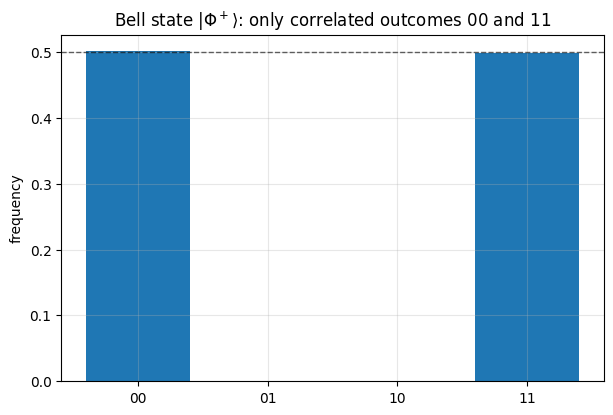

In [5]:
# Visualize the Bell-state outcome distribution
labels = ['00','01','10','11']
freqs = [counts.get(l, 0) for l in labels]
plt.figure()
plt.bar(labels, np.array(freqs)/2000, color=["C0","C3","C3","C0"])
plt.axhline(0.5, color="k", ls="--", lw=1, alpha=0.6)
plt.ylabel("frequency"); plt.title(r"Bell state $|\Phi^+\rangle$: only correlated outcomes 00 and 11")
plt.show()


Across 2000 measurements the Bell state yields only $00$ and $11$, each about half the time — the
outcomes are perfectly correlated, and measuring one qubit fixes the other instantly, regardless of
distance. This is the correlation Einstein called "spooky action at a distance." The next section
shows these correlations are *stronger* than anything a classical (local-realistic) theory permits.

## 4. Entanglement and the CHSH inequality

Could the correlations be explained by the qubits secretly agreeing on answers in advance (a "local
hidden variable" theory)? The **CHSH inequality** turns this philosophical question into a number. For
any local-realistic theory, a particular combination $S$ of correlation measurements obeys

$$
|S| = |E(a,b) - E(a,b') + E(a',b) + E(a',b')| \le 2 ,
$$

where $E(a,b)$ is the correlation when the two qubits are measured along axes $a$ and $b$. Quantum
mechanics, with the right measurement angles on a Bell state, achieves

$$
|S| = 2\sqrt{2} \approx 2.828 ,
$$

the **Tsirelson bound** — a clear violation. We compute $S$ directly from our simulator. Measuring a
qubit "along an axis at angle $\phi$" means measuring the observable
$M(\phi) = \cos\phi\, Z + \sin\phi\, X$, and the correlation is $E = \langle M_A \otimes M_B\rangle$.


In [6]:
def measurement_operator(phi):
    # Observable for measuring along an axis in the X-Z plane at angle phi.
    return np.cos(phi)*Z + np.sin(phi)*X

def correlation(bell_state, phi_a, phi_b):
    # E(a,b) = <psi| M(phi_a) (x) M(phi_b) |psi>
    M = np.kron(measurement_operator(phi_a), measurement_operator(phi_b))
    return np.vdot(bell_state, M @ bell_state).real

# Optimal CHSH angles for |Phi+>
a, a2 = 0.0, np.pi/2
b, b2 = np.pi/4, 3*np.pi/4

E_ab   = correlation(bell, a,  b)
E_ab2  = correlation(bell, a,  b2)
E_a2b  = correlation(bell, a2, b)
E_a2b2 = correlation(bell, a2, b2)

S = E_ab - E_ab2 + E_a2b + E_a2b2
print("E(a,b)  =", round(E_ab, 4))
print("E(a,b') =", round(E_ab2, 4))
print("E(a',b) =", round(E_a2b, 4))
print("E(a',b')=", round(E_a2b2, 4))
print(f"\nCHSH S = {S:.4f}")
print(f"Classical bound: |S| <= 2.0")
print(f"Tsirelson bound: 2*sqrt(2) = {2*np.sqrt(2):.4f}")
print("=> VIOLATION: quantum correlations exceed any local-realistic theory." if abs(S) > 2
      else "no violation")


E(a,b)  = 0.7071
E(a,b') = -0.7071
E(a',b) = 0.7071
E(a',b')= 0.7071

CHSH S = 2.8284
Classical bound: |S| <= 2.0
Tsirelson bound: 2*sqrt(2) = 2.8284
=> VIOLATION: quantum correlations exceed any local-realistic theory.


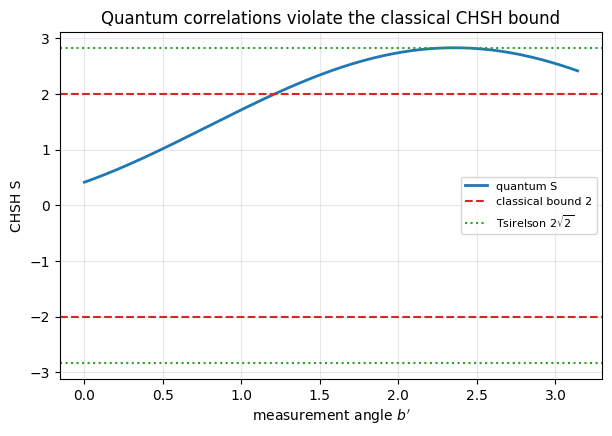

In [7]:
# Sweep the second measurement angle b' to see S cross the classical bound
phis = np.linspace(0, np.pi, 200)
S_vals = []
for p in phis:
    s = (correlation(bell, 0.0, np.pi/4) - correlation(bell, 0.0, p)
         + correlation(bell, np.pi/2, np.pi/4) + correlation(bell, np.pi/2, p))
    S_vals.append(s)
plt.figure()
plt.plot(phis, S_vals, lw=2, label="quantum S")
plt.axhline(2, color="C3", ls="--", label="classical bound 2")
plt.axhline(2*np.sqrt(2), color="C2", ls=":", label=r"Tsirelson $2\sqrt{2}$")
plt.axhline(-2, color="C3", ls="--"); plt.axhline(-2*np.sqrt(2), color="C2", ls=":")
plt.xlabel(r"measurement angle $b'$"); plt.ylabel("CHSH S")
plt.title("Quantum correlations violate the classical CHSH bound"); plt.legend(fontsize=8); plt.show()


Our simulator reproduces $S = 2\sqrt2$ at the optimal angles and shows $S$ exceeding the classical
bound of $2$ across a range of measurement settings. This is not a quirk of the code — it is the
numerical content of Bell's theorem, confirmed in real experiments (Aspect 1982; the 2022 Nobel
Prize). Entanglement is a genuinely non-classical resource, and it is what gives quantum models access
to correlations a classical model would need exponential resources to represent.

## 5. Summary

- **Multi-qubit states** live in the tensor-product space $\mathbb{C}^{2^n}$, whose dimension doubles
  per qubit; joint states and gates combine via the **Kronecker product**.
- **CNOT** (with a Hadamard) creates **entanglement** — states like the Bell state $|\Phi^+\rangle$
  that cannot be factored into individual qubit states.
- **Measurement** follows the **Born rule** ($P(i)=|c_i|^2$) and **collapses** the state; measuring one
  qubit of an entangled pair instantly determines the other.
- The **CHSH inequality** is violated by quantum correlations ($|S|=2\sqrt2 > 2$), proving entanglement
  has no local-realistic explanation.

In Week 3 we put these resources to work: the oracle model, quantum parallelism, and the first
algorithms with a provable quantum advantage — Deutsch–Jozsa, Grover, and the quantum Fourier
transform.


## 6. Exercises

**Exercise 1 (all four Bell states).** Construct $|\Phi^-\rangle, |\Psi^+\rangle, |\Psi^-\rangle$ by
varying the input bits and adding $Z$/$X$ gates before the CNOT. Verify each is entangled and find its
measurement statistics.

**Exercise 2 (no-cloning, informally).** Argue from linearity why no single unitary $U$ can satisfy
$U(|\psi\rangle\otimes|0\rangle) = |\psi\rangle\otimes|\psi\rangle$ for all $|\psi\rangle$. Test a
candidate "copy" circuit numerically and show it fails for a superposition input.

**Exercise 3 (GHZ state).** Build the three-qubit GHZ state
$\tfrac1{\sqrt2}(|000\rangle + |111\rangle)$ with one $H$ and two CNOTs. Measure it many times and
confirm only $000$ and $111$ appear.

**Exercise 4 (reduced state).** For the Bell state, compute the reduced density matrix of qubit 0 by
tracing out qubit 1 (sum the appropriate outer products). Show it equals $\tfrac12 I$ — a single qubit
of a maximally entangled pair looks completely random on its own.


In [8]:
# Scratch space for the exercises.
